This notebook does some comparison between extracted and raw flair data to verify if the extracted data is correct. First we check for some temporary basals (sets to zero temporarily) and auto mode. Then, we compare extracted vs. reported TDD.

## Load Data

In [4]:
#imports
import os
import sys
sys.path.append(os.path.join(os.getcwd(), '..','..'))
from datetime import datetime, timedelta
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
%matplotlib widget

from studies import DCLP3,DCLP5,ReplaceBG,Flair,Loop,PEDAP,IOBP2, T1DEXI, T1DEXIP
from studies.studydataset import StudyDataset
from src import drawing, cdf, tdd, logger, pandas_helper
from src.find_periods import find_periods
from src.date_helper import convert_duration_to_timedelta

import logging
logger = logger.Logger.get_logger("",logging.WARNING)

In [3]:
data_path = os.path.join(os.getcwd(),'..','..','data','raw')
flair = Flair(os.path.join(data_path, 'FLAIRPublicDataSet'))
flair.extract_basal_event_history()
flair.extract_bolus_event_history()
flair.extract_cgm_history()

,patient_id,datetime,cgm
0,26,2019-05-15 21:18:15,136
1,26,2019-05-15 21:13:15,146
2,26,2019-05-15 21:08:15,157
3,26,2019-05-15 21:03:15,166
4,26,2019-05-15 20:58:15,174
...,...,...,...
5508980,75,2019-10-27 00:48:48,128
5508981,75,2019-10-27 00:43:48,133
5508982,75,2019-10-27 00:38:48,142
5508983,75,2019-10-27 00:33:48,160


## Visualize Patient Data

Visualize raw and extracted data of patient 12

/var/folders/m4/5d02b2xs0l52lbxzbk0t3vym0000gp/T/ipykernel_15705/1458147326.py:27: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  drawing.drawTempBasal(ax, tmpBasals.DateTime.dt.to_pydatetime(),


Text(0.5, 1.0, 'Basal and micro-boluses for patient 12')

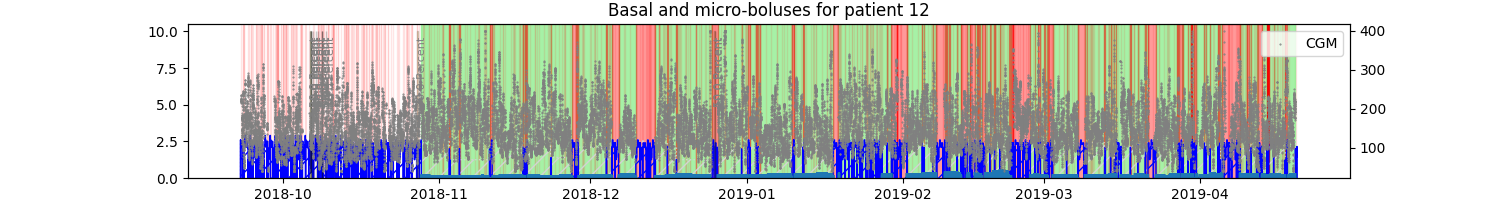

In [6]:
#get patient data
patient = 12
#raw
sub_df_pump = flair.df_pump.loc[flair.df_pump.PtID == patient].sort_values('DateTime')
sub_df_cgm = flair.df_cgm.loc[flair.df_cgm.PtID == patient].sort_values('DateTime')

#extracted 
basal_events_extracted = flair.extract_basal_event_history()
basal_events_extracted = basal_events_extracted[basal_events_extracted.patient_id==str(patient)]

#draw 
f = plt.figure(figsize=(15,2)); ax = f.gca(); twin_ax = ax.twinx()

#raw basals
basals_raw = sub_df_pump.dropna(subset=['BasalRt'])
drawing.drawAbsoluteBasalRates(ax, basals_raw.DateTime.values, basals_raw.BasalRt.values,edgecolor='lightgray',linestyle=':')

#extracted basals
drawing.drawAbsoluteBasalRates(ax, 
                               basal_events_extracted.datetime.values,
                               basal_events_extracted.basal_rate.values, edgecolor='blue', linestyle='-')


# temp basals
tmpBasals = sub_df_pump.dropna(subset=['TempBasalAmt'],axis=0)
if len(tmpBasals)>0:
    drawing.drawTempBasal(ax, tmpBasals.DateTime.dt.to_pydatetime(), 
                          tmpBasals.TempBasalAmt.values, 
                          tmpBasals.TempBasalDur.values,
                           tmpBasals.TempBasalType.values)

#suspends
suspends = sub_df_pump.dropna(subset=['Suspend'])
susupend_periods_on = find_periods(suspends, 'Suspend', 'DateTime',lambda x: x != 'NORMAL_PUMPING', lambda x: x == 'NORMAL_PUMPING')
for period in susupend_periods_on:
    ax.axvspan(period.time_start, period.time_end, color='red', zorder=0.2, alpha=0.1, 
               label='suspend' if period == susupend_periods_on[0] else None)

#

## Auto Mode Status
on_periods = find_periods(sub_df_pump, 'AutoModeStatus', 'DateTime', lambda x: x, lambda x: not x)
off_periods = find_periods(sub_df_pump, 'AutoModeStatus', 'DateTime', lambda x: not x, lambda x: x)
#background on (green)
for period in on_periods:
    ax.axvspan(period.time_start, period.time_end, color='lightgreen', alpha=0.8,zorder=0.1, label='CL on' if period == on_periods[0] else None)
#background off (red)
for period in off_periods:
    ax.axvspan(period.time_start, period.time_end, color='red', alpha=0.4,zorder=0.2, label='CL off' if period == off_periods[0] else None)
# #on events
# temp = sub_df_pump.loc[sub_df_pump.AutoModeStatus==True]
# if len(temp)>0:
#     ax.scatter(temp.DateTime, np.ones(len(temp))*3, marker='^', color='green', label='AutoModeStatus True')
# #off events
# temp = sub_df_pump.loc[sub_df_pump.AutoModeStatus==False]
# if len(temp)>0:
#     ax.scatter(temp.DateTime, np.ones(len(temp))*3, marker='v', color='red', label='AutoModeStatus False')

#micro boluses
micro_boluses = sub_df_pump[sub_df_pump.BolusSource.isin(['CL_MICRO_BOLUS', 'CLOSED_LOOP_MICRO_BOLUS'])]
if len(micro_boluses)>0:
    ax.stem(micro_boluses.DateTime.values, micro_boluses.BolusDeliv.values, linefmt='C0-', markerfmt='None', basefmt='None', label='micro',)

#cgm
if len(sub_df_cgm)>0:
    twin_ax.scatter(sub_df_cgm.DateTime, sub_df_cgm.CGM, label='CGM', color='gray', marker='.',s=1)

plt.legend(loc='upper right')
plt.title(f"Basal and micro-boluses for patient {patient}")

#plt.xlim(sub_df_pump.DateTime.min(), sub_df_pump.DateTime.min()+timedelta(days=1))



## TDDs

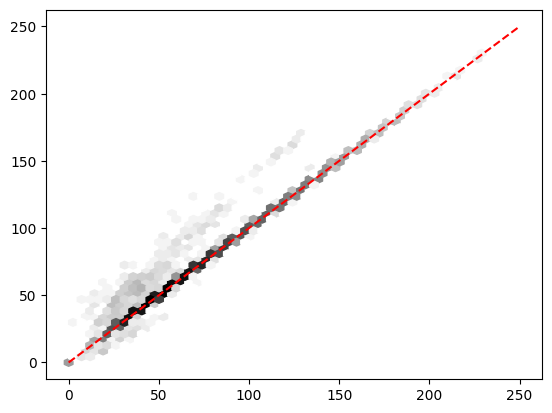

In [ ]:
tdd_reported = flair.get_reported_tdds().set_index(['patient_id','date']).drop(columns=['datetime']).rename(columns={'tdd':'tdd_reported'})
tdd_basal_extracted = flair.extract_basal_event_history().groupby('patient_id').apply(tdd.calculate_daily_basal_dose, include_groups=False);
tdd_bolus_extracted = flair.extract_bolus_event_history().groupby('patient_id').apply(tdd.calculate_daily_bolus_dose, include_groups=False);
tdds = pd.concat([tdd_basal_extracted, tdd_bolus_extracted, tdd_reported], axis=1).sort_index()
tdds['tdd_extracted']= tdds[['basal','bolus']].sum(axis=1)
plt.hexbin(tdds.tdd_reported, tdds.tdd_extracted, gridsize=50, cmap='Greys', bins='log')
plt.plot([0,250],[0,250], '--r')

## temp events
Get zero temp events and plot extracted data around the zero temp event and draw the raw data. 
Do they match?

In [3]:
basals = flair.extract_basal_event_history()

In [4]:
#get sample where we know there is a temporary basal
zero_temps = flair.df_pump[flair.df_pump.TempBasalAmt==0]

,RecID,PtID,DataDtTm,BasalRt,TempBasalAmt,TempBasalType,TempBasalDur,BolusType,BolusDeliv,ExtendBolusDuration,Suspend,BolusSource,TDD,AutoModeStatus,DateTime
821502,821503,96,4/17/2019 3:07:54 AM,NaN,0.0,Percent,0:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-04-17 03:07:54


,patient_id,datetime,basal_rate
821704,96,2019-04-16 15:46:00,1.820
821703,96,2019-04-16 16:00:00,1.950
821702,96,2019-04-16 16:16:00,1.500
821629,96,2019-04-17 00:00:00,1.000
821625,96,2019-04-17 00:20:16,0.000
821618,96,2019-04-17 00:44:55,1.000
821616,96,2019-04-17 01:15:15,0.000
821610,96,2019-04-17 01:42:52,1.000
821554,96,2019-04-17 02:00:00,1.100
821545,96,2019-04-17 02:41:00,2.035


,RecID,PtID,DataDtTm,BasalRt,TempBasalAmt,TempBasalType,TempBasalDur,Suspend,DateTime
821536,821537,96,4/17/2019 2:45:52 AM,NaN,NaN,NaN,NaN,NaN,2019-04-17 02:45:52
821535,821536,96,4/17/2019 2:47:00 AM,1.1,NaN,NaN,NaN,NaN,2019-04-17 02:47:00
821534,821535,96,4/17/2019 3:05:16 AM,NaN,NaN,NaN,NaN,NaN,2019-04-17 03:05:16
821533,821534,96,4/17/2019 3:07:08 AM,NaN,NaN,NaN,NaN,NaN,2019-04-17 03:07:08
821532,821533,96,4/17/2019 3:07:13 AM,NaN,NaN,NaN,NaN,NaN,2019-04-17 03:07:13
821505,821506,96,4/17/2019 3:07:17 AM,NaN,NaN,NaN,NaN,NaN,2019-04-17 03:07:17
821504,821505,96,4/17/2019 3:07:23 AM,NaN,NaN,NaN,NaN,NaN,2019-04-17 03:07:23
821503,821504,96,4/17/2019 3:07:25 AM,NaN,NaN,NaN,NaN,NaN,2019-04-17 03:07:25
821502,821503,96,4/17/2019 3:07:54 AM,NaN,0.0,Percent,0:45:00,NaN,2019-04-17 03:07:54
821501,821502,96,4/17/2019 3:08:00 AM,1.1,NaN,NaN,NaN,NaN,2019-04-17 03:08:00


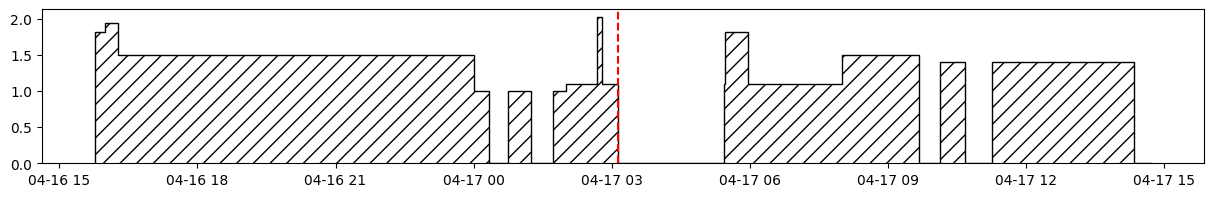

In [5]:
#draw sample
sample = zero_temps.sample()
datetime = pd.to_datetime(sample.DateTime.values[0])
patient_id = str(sample.PtID.values[0])
display(sample)

#get surrounding rows of extracted data
temp = basals[(basals.patient_id==patient_id) & (basals.datetime< (datetime+timedelta(hours=12))) & (basals.datetime > (datetime-timedelta(hours=12)))]
display(temp)

#display surrounding raw data
context = pandas_helper.extract_surrounding_rows(flair.df_pump.loc[flair.df_pump.PtID==sample.PtID.values[0]], sample.index[0],8,sort_by=['PtID','DateTime'])
display(context.dropna(axis=1, how='all'))

#plot
plt.figure(figsize=(15,2)) ; ax=plt.gca()
drawing.drawAbsoluteBasalRates(ax,temp.datetime.values, temp.basal_rate.values)
#mark the sample event
plt.axvline(datetime, color='r', linestyle='--')


As we can see, the extracted data shows temporary 0 rates when the temporary event in the raw data is present

## AutoModeStatus
Here, we check if a auto mode status on successfully causes a zero basal rate.

In [6]:
#get sample where we know there is a temporary basal
cl_mdes = flair.df_pump[flair.df_pump.AutoModeStatus==True]

,RecID,PtID,DataDtTm,BasalRt,TempBasalAmt,TempBasalType,TempBasalDur,BolusType,BolusDeliv,ExtendBolusDuration,Suspend,BolusSource,TDD,AutoModeStatus,DateTime
2315937,2380683,37,4/19/2019 12:54:49 PM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,2019-04-19 12:54:49


,patient_id,datetime,basal_rate
2315960,37,2019-04-19 07:47:00,2.2
2315953,37,2019-04-19 09:16:36,0.0
2315951,37,2019-04-19 09:56:26,2.2
2315949,37,2019-04-19 10:06:58,0.0
2315945,37,2019-04-19 10:10:23,2.2
2315937,37,2019-04-19 12:54:49,0.0
2315185,37,2019-04-19 23:31:32,0.0
2315183,37,2019-04-19 23:31:44,0.0


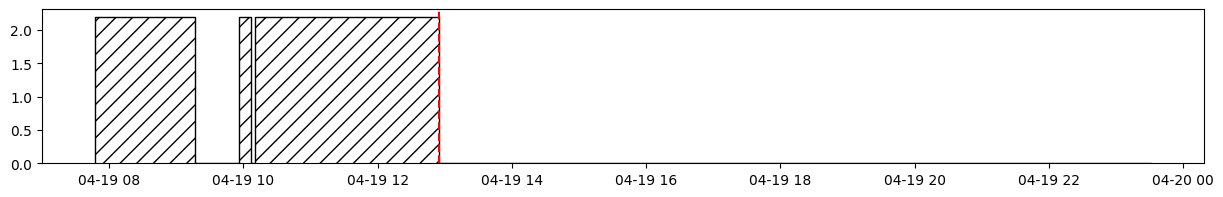

,RecID,PtID,DataDtTm,BolusType,BolusDeliv,Suspend,BolusSource,AutoModeStatus,DateTime
2315945,2380691,37,4/19/2019 10:10:23 AM,NaN,NaN,NORMAL_PUMPING,NaN,NaN,2019-04-19 10:10:23
2315946,2380692,37,4/19/2019 10:10:23 AM,NaN,NaN,NaN,NaN,NaN,2019-04-19 10:10:23
2315944,2380690,37,4/19/2019 10:58:21 AM,NaN,NaN,NaN,NaN,NaN,2019-04-19 10:58:21
2315942,2380688,37,4/19/2019 10:58:21 AM,Normal,NaN,NaN,BOLUS_WIZARD,NaN,2019-04-19 10:58:21
2315943,2380689,37,4/19/2019 10:58:21 AM,NaN,NaN,NaN,NaN,NaN,2019-04-19 10:58:21
2315941,2380687,37,4/19/2019 11:04:46 AM,Normal,9.60,NaN,BOLUS_WIZARD,NaN,2019-04-19 11:04:46
2315940,2380686,37,4/19/2019 12:54:38 PM,NaN,NaN,NaN,NaN,NaN,2019-04-19 12:54:38
2315938,2380684,37,4/19/2019 12:54:46 PM,NaN,NaN,NaN,NaN,NaN,2019-04-19 12:54:46
2315939,2380685,37,4/19/2019 12:54:46 PM,NaN,NaN,NaN,NaN,NaN,2019-04-19 12:54:46
2315936,2380682,37,4/19/2019 12:54:47 PM,NaN,NaN,NaN,NaN,NaN,2019-04-19 12:54:47


In [7]:
sample = cl_mdes.sample()
datetime = pd.to_datetime(sample.DateTime.values[0])
patient_id = str(sample.PtID.values[0])
display(sample)

#show surrounding extracted data
temp = basals[(basals.patient_id==patient_id) & (basals.datetime< (datetime+timedelta(hours=12))) & (basals.datetime > (datetime-timedelta(hours=12)))]
display(temp)

#plot the extracted basal rates
plt.figure(figsize=(15,2)) ; ax=plt.gca()
drawing.drawAbsoluteBasalRates(ax,temp.datetime.values, temp.basal_rate.values)
plt.axvline(datetime, color='r', linestyle='--')
plt.show()

#show context of raw data
context = pandas_helper.extract_surrounding_rows(flair.df_pump, sample.index[0],10,sort_by=['PtID','DateTime'])
display(context.dropna(axis=1, how='all'))

As we can see, the extracted data basal rate returns to zero when the closed loop mode is activated